In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
thermal = pd.read_csv(
    "../../data/external/m5_historical/historical_thermal_events.csv"
)

print("Rows:", len(thermal))
print("Columns:", len(thermal.columns))

Rows: 162355
Columns: 35


In [4]:
thermal.head()

,event_id,start_time,end_time,duration_hours,centroid_lat,centroid_lon,spatial_extent_km,detection_count,unique_satellite_count,satellites,...,nearest_facility_type,nearest_facility_name,distance_to_facility_km,thermal_intensity,thermal_frp_variability,thermal_frp_per_detection,thermal_frp_per_hour,thermal_detection_density,thermal_persistence_indicator,thermal_concentration_indicator
0,TT-EVT-00000066,2025-09-02T07:37:00,2025-09-02T07:37:00,0.0,9.076645,77.972445,0.378393,2,1,N21,...,POWER_PLANT,NaN,0.603738,15.865621,0.030295,3.795,75.900000,4.180664,0.0,0.515084
1,TT-EVT-00000067,2025-09-02T07:37:00,2025-09-02T07:37:00,0.0,9.095805,78.053930,0.300414,2,1,N21,...,POWER_PLANT,NaN,0.472502,22.127113,0.255021,4.430,88.600000,4.994834,0.0,0.627469
2,TT-EVT-00000068,2025-09-02T07:37:00,2025-09-02T07:37:00,0.0,9.111580,77.542840,0.265633,2,1,N21,...,POWER_PLANT,NaN,1.331222,19.883320,0.213146,3.635,72.700000,5.469964,0.0,0.606519
3,TT-EVT-00000069,2025-09-02T07:37:00,2025-09-02T07:37:00,0.0,9.141570,78.180790,0.000000,1,1,N21,...,POWER_PLANT,NaN,3.454019,53.699997,0.000000,5.370,53.699997,10.000000,0.0,0.999814
4,TT-EVT-00000081,2025-09-02T08:27:00,2025-09-02T08:27:00,0.0,8.786930,77.857040,0.000000,1,1,N20,...,POWER_PLANT,NaN,0.362720,20.000000,0.000000,2.000,20.000000,10.000000,0.0,0.999500


In [5]:
print(thermal.columns.tolist())

['event_id', 'start_time', 'end_time', 'duration_hours', 'centroid_lat', 'centroid_lon', 'spatial_extent_km', 'detection_count', 'unique_satellite_count', 'satellites', 'max_frp_mw', 'mean_frp_mw', 'median_frp_mw', 'sum_frp_mw', 'event_quality', 'year', 'month', 'day', 'day_of_week', 'hour', 'season', 'is_day', 'is_night', 'is_weekend', 'nearest_facility_id', 'nearest_facility_type', 'nearest_facility_name', 'distance_to_facility_km', 'thermal_intensity', 'thermal_frp_variability', 'thermal_frp_per_detection', 'thermal_frp_per_hour', 'thermal_detection_density', 'thermal_persistence_indicator', 'thermal_concentration_indicator']


In [6]:
thermal["start_time"] = pd.to_datetime(thermal["start_time"])
thermal["end_time"] = pd.to_datetime(thermal["end_time"])

print("Observation start:", thermal["start_time"].min())
print("Observation end:", thermal["end_time"].max())
print("Number of days:", (thermal["end_time"].max() - thermal["start_time"].min()).days + 1)

Observation start: 2025-09-02 07:37:00
Observation end: 2026-09-02 08:37:00
Number of days: 366


In [7]:
thermal["nearest_facility_type"].value_counts()

nearest_facility_type
INDUSTRIAL_AREA     62658
QUARRY              45131
POWER_PLANT         30144
FACTORY             11663
STORAGE_FACILITY     7738
WASTE_PROCESSING     3867
MINE                  354
CEMENT_PLANT          345
REFINERY              235
OIL_GAS               124
STEEL_PLANT            70
CHEMICAL_PLANT         26
Name: count, dtype: int64

In [8]:
facility_event_counts = (
    thermal.groupby("nearest_facility_id")
    .size()
    .reset_index(name="total_events")
)

print("Facilities with historical events:", len(facility_event_counts))
print()
print(facility_event_counts["total_events"].describe())

Facilities with historical events: 23558

count    23558.000000
mean         6.891714
std         22.972694
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max        676.000000
Name: total_events, dtype: float64


In [9]:
facility_event_counts.sort_values(
    "total_events",
    ascending=False
).head(10)

,nearest_facility_id,total_events
8296,928075506,676
8605,968271870,655
242,117858814,574
236,117807506,557
234,117807504,554
9596,988918471,540
9590,988893557,530
232,117695917,522
79,77362486,514
238,117807509,486


In [10]:
facility_info = thermal[
    [
        "nearest_facility_id",
        "nearest_facility_type",
        "nearest_facility_name"
    ]
].drop_duplicates("nearest_facility_id")

top_facilities = (
    facility_event_counts
    .sort_values("total_events", ascending=False)
    .head(10)
    .merge(
        facility_info,
        on="nearest_facility_id",
        how="left"
    )
)

top_facilities

,nearest_facility_id,total_events,nearest_facility_type,nearest_facility_name
0,928075506,676,QUARRY,Ananta coal mine
1,968271870,655,QUARRY,Basundhara (West) Coal Mine
2,117858814,574,QUARRY,NaN
3,117807506,557,QUARRY,Amalgamated Keshalpur-West Mudidih (AKWMC) Coa...
4,117807504,554,QUARRY,Cluster 8 and Cluster 9 Coal Mines
5,988918471,540,QUARRY,NaN
6,988893557,530,QUARRY,Bhubhaneshwari coal mine
7,117695917,522,QUARRY,Cluster 11 and Cluster 7 (BCCL) Coal Mines
8,77362486,514,QUARRY,Chirimiri Coal Mine
9,117807509,486,QUARRY,NaN


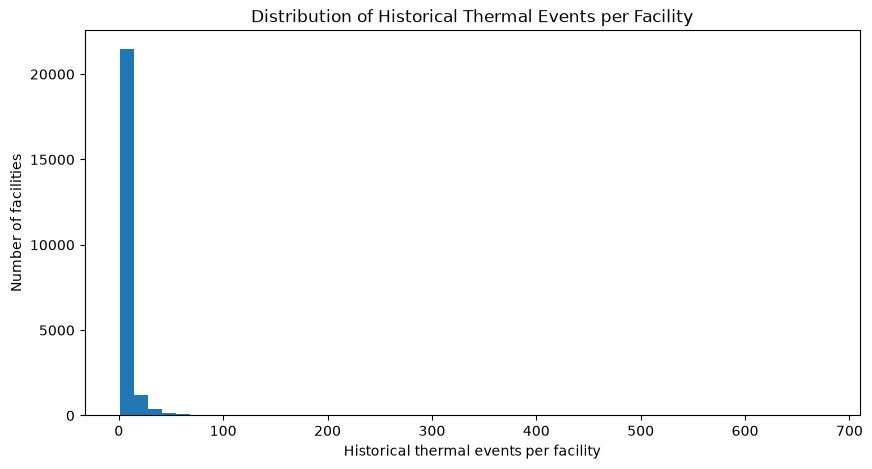

In [11]:
plt.figure(figsize=(10, 5))

plt.hist(
    facility_event_counts["total_events"],
    bins=50
)

plt.xlabel("Historical thermal events per facility")
plt.ylabel("Number of facilities")
plt.title("Distribution of Historical Thermal Events per Facility")

plt.show()

In [12]:
print("Mean FRP:")
print(thermal["mean_frp_mw"].describe())

print("\nMaximum FRP:")
print(thermal["max_frp_mw"].describe())

print("\nThermal Intensity:")
print(thermal["thermal_intensity"].describe())

Mean FRP:
count    162355.000000
mean          4.253191
std           4.599685
min           0.070000
25%           1.590000
50%           3.090000
75%           5.448750
max         358.140000
Name: mean_frp_mw, dtype: float64

Maximum FRP:
count    162355.000000
mean          4.920920
std           6.702932
min           0.070000
25%           1.760000
50%           3.360000
75%           5.990000
max         561.740000
Name: max_frp_mw, dtype: float64

Thermal Intensity:
count    162355.000000
mean         33.950207
std          38.159216
min           0.643782
25%          11.190988
50%          24.000000
75%          43.500000
max        2606.000000
Name: thermal_intensity, dtype: float64


In [13]:
thermal_baseline = (
    thermal.groupby("nearest_facility_id")
    .agg(
        avg_frp_mw=("mean_frp_mw", "mean"),
        median_frp_mw=("mean_frp_mw", "median"),
        max_frp_mw=("max_frp_mw", "max"),
        min_frp_mw=("mean_frp_mw", "min"),
        avg_thermal_intensity=("thermal_intensity", "mean"),
        max_thermal_intensity=("thermal_intensity", "max")
    )
    .reset_index()
)

print("Facilities:", len(thermal_baseline))
thermal_baseline.head()

Facilities: 23558


,nearest_facility_id,avg_frp_mw,median_frp_mw,max_frp_mw,min_frp_mw,avg_thermal_intensity,max_thermal_intensity
0,26546597,6.922222,7.610,12.94,1.10,60.599234,90.400000
1,26643216,2.240000,1.710,3.64,1.37,22.400000,36.400000
2,26685581,0.700000,0.700,0.70,0.70,7.000000,7.000000
3,26688209,1.180000,1.180,1.41,1.18,7.482887,7.482887
4,26717419,0.535000,0.535,0.57,0.50,5.350000,5.700000


In [14]:
temporal_baseline = (
    thermal.groupby("nearest_facility_id")
    .agg(
        day_events=("is_day", "sum"),
        night_events=("is_night", "sum"),
        weekday_events=("is_weekend", lambda x: (~x).sum()),
        weekend_events=("is_weekend", "sum")
    )
    .reset_index()
)

print("Facilities:", len(temporal_baseline))
temporal_baseline.head()


Facilities: 23558


,nearest_facility_id,day_events,night_events,weekday_events,weekend_events
0,26546597,5,1,6,0
1,26643216,1,2,2,1
2,26685581,0,1,1,0
3,26688209,0,1,1,0
4,26717419,0,2,2,0


In [15]:
hour_counts = (
    thermal.groupby(["nearest_facility_id", "hour"])
    .size()
    .reset_index(name="event_count")
)

most_active_hour = (
    hour_counts.loc[
        hour_counts.groupby("nearest_facility_id")["event_count"].idxmax()
    ]
    .rename(columns={"hour": "most_active_hour"})
    [["nearest_facility_id", "most_active_hour", "event_count"]]
)

print("Facilities:", len(most_active_hour))
most_active_hour.head()

Facilities: 23558


,nearest_facility_id,most_active_hour,event_count
0,26546597,7,3
3,26643216,7,1
6,26685581,20,1
7,26688209,19,1
8,26717419,19,1


In [16]:
thermal["year_month"] = thermal["start_time"].dt.to_period("M")

active_months = (
    thermal.groupby("nearest_facility_id")["year_month"]
    .nunique()
    .reset_index(name="active_months")
)

print("Facilities:", len(active_months))
print()
print(active_months["active_months"].describe())

Facilities: 23558

count    23558.000000
mean         2.270014
std          1.801918
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         13.000000
Name: active_months, dtype: float64


In [17]:
monthly_events = (
    thermal.groupby(
        ["nearest_facility_id", "year_month"]
    )
    .size()
    .reset_index(name="monthly_events")
)

monthly_baseline = (
    monthly_events.groupby("nearest_facility_id")["monthly_events"]
    .agg(
        avg_events_per_month="mean",
        median_events_per_month="median",
        max_events_per_month="max"
    )
    .reset_index()
)

print("Facilities:", len(monthly_baseline))
monthly_baseline.head()

Facilities: 23558


,nearest_facility_id,avg_events_per_month,median_events_per_month,max_events_per_month
0,26546597,6.0,6.0,6
1,26643216,1.5,1.5,2
2,26685581,1.0,1.0,1
3,26688209,1.0,1.0,1
4,26717419,2.0,2.0,2


In [18]:
spatial_baseline = (
    thermal.groupby("nearest_facility_id")
    .agg(
        avg_distance_km=("distance_to_facility_km", "mean"),
        median_distance_km=("distance_to_facility_km", "median"),
        max_distance_km=("distance_to_facility_km", "max")
    )
    .reset_index()
)

print("Facilities:", len(spatial_baseline))
spatial_baseline.head()

Facilities: 23558


,nearest_facility_id,avg_distance_km,median_distance_km,max_distance_km
0,26546597,2.055056,1.678554,4.460504
1,26643216,0.894838,0.834985,1.087056
2,26685581,0.395893,0.395893,0.395893
3,26688209,1.992845,1.992845,1.992845
4,26717419,1.307920,1.307920,1.927663


In [19]:
duration_baseline = (
    thermal.groupby("nearest_facility_id")
    .agg(
        avg_duration_hours=("duration_hours", "mean"),
        median_duration_hours=("duration_hours", "median"),
        max_duration_hours=("duration_hours", "max"),
        avg_detection_count=("detection_count", "mean"),
        max_detection_count=("detection_count", "max")
    )
    .reset_index()
)

print("Facilities:", len(duration_baseline))
duration_baseline.head()

Facilities: 23558


,nearest_facility_id,avg_duration_hours,median_duration_hours,max_duration_hours,avg_detection_count,max_detection_count
0,26546597,0.286111,0.0,0.866667,2.0,6
1,26643216,0.000000,0.0,0.000000,1.0,1
2,26685581,0.000000,0.0,0.000000,1.0,1
3,26688209,0.000000,0.0,0.000000,2.0,2
4,26717419,0.000000,0.0,0.000000,1.0,1


In [20]:
print("Total events:", len(thermal))

print(
    "Day + night:",
    thermal["is_day"].sum() + thermal["is_night"].sum()
)

print(
    "Weekday + weekend:",
    (~thermal["is_weekend"]).sum() + thermal["is_weekend"].sum()
)

Total events: 162355
Day + night: 162355
Weekday + weekend: 162355


In [21]:
baseline = pd.read_csv(
    "../../data/baselines/facility_baselines.csv"
)

print("Rows:", len(baseline))
print("Columns:", len(baseline.columns))
print(baseline.columns.tolist())

Rows: 23558
Columns: 44
['facility_id', 'name', 'operator', 'facility_category', 'landuse', 'industrial', 'man_made', 'power', 'building', 'source', 'longitude', 'latitude', 'total_events', 'active_days', 'avg_events_per_month', 'median_events_per_month', 'active_months', 'events_per_30_days', 'mean_frp_mw', 'median_frp_mw', 'max_frp_mw', 'min_frp_mw', 'mean_thermal_intensity', 'max_thermal_intensity', 'most_active_hour', 'most_active_month', 'day_events', 'night_events', 'weekday_events', 'weekend_events', 'mean_distance_km', 'median_distance_km', 'max_distance_km', 'mean_spatial_extent_km', 'max_spatial_extent_km', 'mean_duration_hours', 'median_duration_hours', 'max_duration_hours', 'mean_detection_count', 'median_detection_count', 'max_detection_count', 'mean_satellite_count', 'max_satellite_count', 'historical_event_observations']


In [22]:
baseline.head()

,facility_id,name,operator,facility_category,landuse,industrial,man_made,power,building,source,...,max_spatial_extent_km,mean_duration_hours,median_duration_hours,max_duration_hours,mean_detection_count,median_detection_count,max_detection_count,mean_satellite_count,max_satellite_count,historical_event_observations
0,26546597,Hindustan Photo Films,NaN,INDUSTRIAL_AREA,industrial,NaN,NaN,NaN,NaN,NaN,...,0.837190,0.286111,0.0,0.866667,2.0,1.0,6,1.333333,2,6
1,26643216,NaN,NaN,INDUSTRIAL_AREA,industrial,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.0,0.000000,1.0,1.0,1,1.000000,1,3
2,26685581,Ramnagar industrial area,NaN,INDUSTRIAL_AREA,industrial,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.0,0.000000,1.0,1.0,1,1.000000,1,1
3,26688209,NaN,NaN,WASTE_PROCESSING,NaN,NaN,wastewater_plant,NaN,NaN,NaN,...,0.215386,0.000000,0.0,0.000000,2.0,2.0,2,1.000000,1,1
4,26717419,NaN,NaN,WASTE_PROCESSING,NaN,NaN,wastewater_plant,NaN,NaN,NaN,...,0.000000,0.000000,0.0,0.000000,1.0,1.0,1,1.000000,1,2


In [23]:
print("Duplicate facility IDs:", baseline["facility_id"].duplicated().sum())
print("Missing facility IDs:", baseline["facility_id"].isna().sum())
print("Total historical events:", baseline["total_events"].sum())
print("Minimum total events:", baseline["total_events"].min())
print("Maximum total events:", baseline["total_events"].max())

Duplicate facility IDs: 0
Missing facility IDs: 0
Total historical events: 162355
Minimum total events: 1
Maximum total events: 676
